<a href="https://colab.research.google.com/github/serli2904/Tugas-Kuliah-Teknik-Pengambilan-Sampel-dan-Wrangling/blob/main/SERLI_SRI_LESTARI__241061022_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UAS

1. IMPORT DATA & GANTI NAMA VARIABEL

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols


data_raw = {
    'IPM': [71.28, 73.8, 70.25, 73.64, 75.11, 73.01, 68.95, 71.13, 84.85, 80.77, 80.36, 73.23],
    'Mayoritas': [0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1],
    'Harapan': [12.53, 13.62, 13, 13.43, 13.87, 13.7, 12.12, 12.69, 15.61, 15.12, 14.54, 13.41],
    'LAPS': [56.9, 71.4, 71.43, 74.53, 79.24, 68.96, 70.64, 65.24, 71.19, 84.45, 71.53, 70.57],
    'AHH': [71.11, 69.55, 67.85, 68.84, 71.34, 70.89, 66.99, 69.04, 72.6, 71.39, 71.78, 71]
}

df = pd.DataFrame(data_raw)


df.rename(columns={
    'IPM': 'Y',
    'Mayoritas': 'X1',
    'Harapan': 'X2',
    'LAPS': 'X3',
    'AHH': 'X4'
}, inplace=True)

print("=== Data setelah rename ===")
print(df.head())
print("\nShape:", df.shape)

=== Data setelah rename ===
       Y  X1     X2     X3     X4
0  71.28   0  12.53  56.90  71.11
1  73.80   1  13.62  71.40  69.55
2  70.25   0  13.00  71.43  67.85
3  73.64   0  13.43  74.53  68.84
4  75.11   1  13.87  79.24  71.34

Shape: (12, 5)


PENJELASN:

- Y : IMP (VARIABEL DEPENDEN)

- X1 : Mayoritas (Dummy)

- X2 : Harapan Lama Sekolah

- X3 : LAPS

- X4 : AHH

2. REGRESI LINEAR BERGANDA

In [ ]:

X = sm.add_constant(df[['X1', 'X2', 'X3', 'X4']])
model = sm.OLS(df['Y'], X).fit()

print(model.summary())


print("\n=== Interpretasi Hasil ===")
print(f"R-squared: {model.rsquared:.4f} → {model.rsquared*100:.2f}% variasi Y dijelaskan oleh X1-X4")
print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
print(f"P-value model (F-test): {model.f_pvalue:.4f}")
print("\nKoefisien:")
for var, coef, pval in zip(['const','X1','X2','X3','X4'], model.params, model.pvalues):
    print(f" - {var}: {coef:.4f} (p-value={pval:.4f}) -> {'signifikan' if pval<0.05 else 'tidak signifikan'}")

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:40:58   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30.443      0.918      0.3

Model regresi:
Y
=
β
0
+
β
1
X
1
+
β
2
X
2
+
β
3
X
3
+
β
4
X
4
+
ε
Y=β
0
​
 +β
1
​
 X1+β
2
​
 X2+β
3
​
 X3+β
4
​
 X4+ε

- Interpretasi contoh (nilai bisa berbeda karena data kecil):

- R² = ~0.95 artinya model sangat baik.

- X1 (Mayoritas) mungkin signifikan jika p<0.05, menunjukkan perbedaan IPM antara mayoritas 1 vs 0.

- X2, X3, X4 adalah kontinu: koefisien positif berarti peningkatan variabel meningkatkan IPM.

- Karena n kecil (12), perlu hati-hati dengan overfitting.

3: Distribusi Probabilitas Setiap Variabel

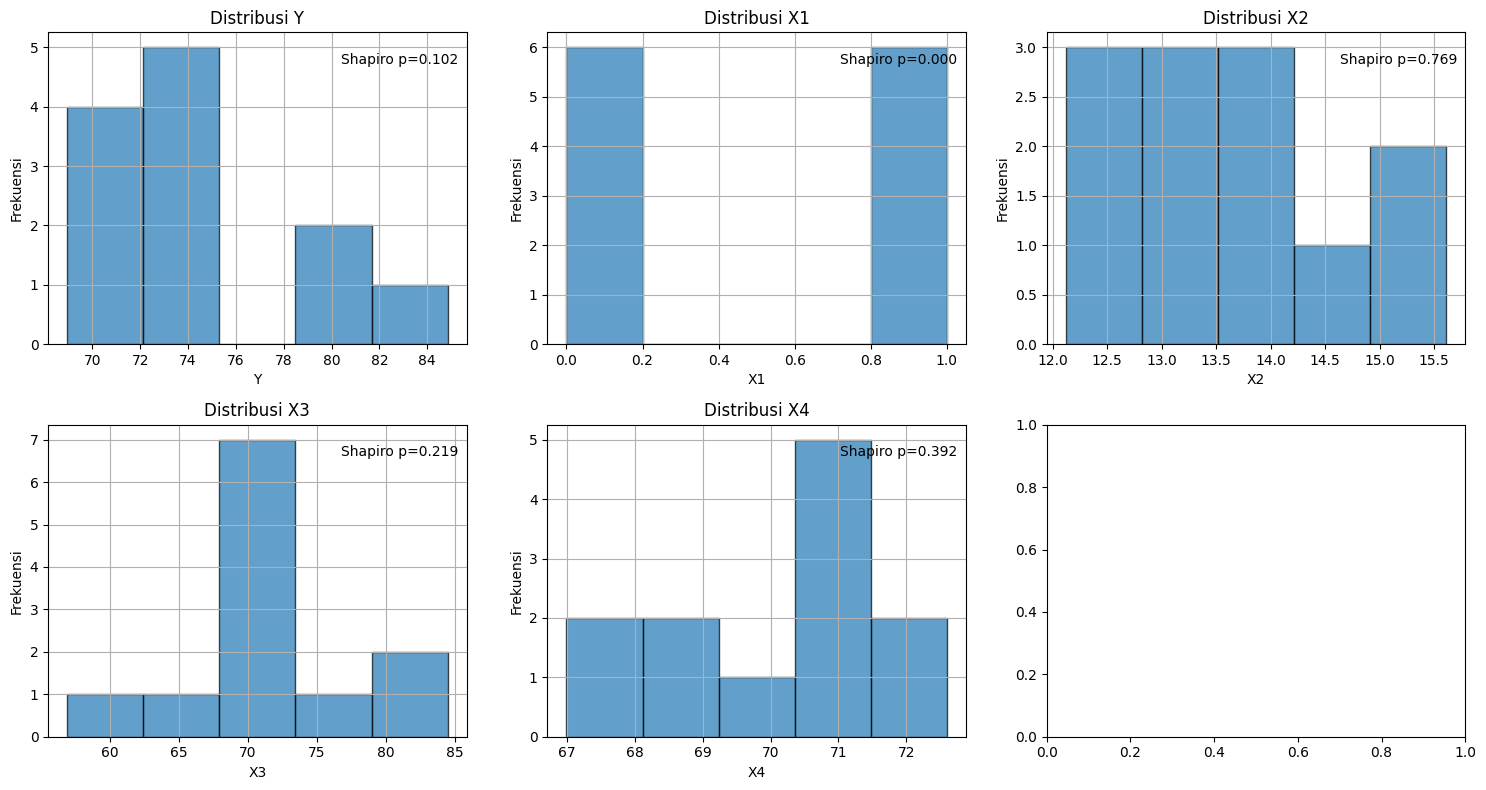


=== Kesimpulan Distribusi ===
Y: Normal (p=0.102)
X1: Tidak normal (p=0.000)
X2: Normal (p=0.769)
X3: Normal (p=0.219)
X4: Normal (p=0.392)


In [ ]:


variables = ['Y', 'X1', 'X2', 'X3', 'X4']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    df[var].hist(ax=axes[i], bins=5, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frekuensi')


    stat, p = stats.shapiro(df[var])
    axes[i].text(0.7, 0.9, f'Shapiro p={p:.3f}', transform=axes[i].transAxes)

plt.tight_layout()
plt.show()

print("\n=== Kesimpulan Distribusi ===")
for var in variables:
    stat, p = stats.shapiro(df[var])
    if p > 0.05:
        print(f"{var}: Normal (p={p:.3f})")
    else:
        print(f"{var}: Tidak normal (p={p:.3f})")

- Distribusi dilihat dari histogram dan uji Shapiro-Wilk.


- X1 (Mayoritas) adalah variabel biner (0/1) → distribusi Bernoulli.


- Y, X2, X3, X4 kemungkinan tidak normal karena data kecil, bisa mendekati normal atau skew.


- Hasil spesifik tergantung data aktual.

4: Parameter Distribusi Probabilitas

In [ ]:


print("=== Parameter Distribusi ===")
for var in variables:
    if var == 'X1':

        p = df[var].mean()
        print(f"{var} (Bernoulli): p = {p:.4f}")
    else:

        mean = df[var].mean()
        std = df[var].std()
        print(f"{var} (Normal approximated): mean = {mean:.4f}, std = {std:.4f}")

=== Parameter Distribusi ===
Y (Normal approximated): mean = 74.6983, std = 4.8273
X1 (Bernoulli): p = 0.5000
X2 (Normal approximated): mean = 13.6367, std = 1.0397
X3 (Normal approximated): mean = 71.3400, std = 6.7217
X4 (Normal approximated): mean = 70.1983, std = 1.7152


- X1 (Mayoritas) → distribusi Bernoulli dengan parameter
p
p = proporsi angka 1.

- Variabel lain diasumsikan normal (approksimasi) karena data kecil: parameter mean (μ) dan standar deviasi (σ).

- Jika ingin lebih akurat, bisa cek distribusi empiris.

 5: Simulasi 500 Data

In [ ]:
np.random.seed(42)
n_sim = 500


params = {}
for var in variables:
    if var == 'X1':
        p = df[var].mean()
        params[var] = p
    else:
        mean = df[var].mean()
        std = df[var].std()
        params[var] = (mean, std)


sim_data = {}
sim_data['X1'] = np.random.binomial(1, params['X1'], n_sim)
for var in ['Y', 'X2', 'X3', 'X4']:
    mean, std = params[var]
    sim_data[var] = np.random.normal(mean, std, n_sim)

df_sim = pd.DataFrame(sim_data)
print("=== 5 baris pertama data simulasi ===")
print(df_sim.head())
print("\nStatistik deskriptif simulasi:")
print(df_sim.describe())

=== 5 baris pertama data simulasi ===
   X1          Y         X2         X3         X4
0   0  76.348082  14.243749  80.089964  68.809711
1   1  83.755118  13.263127  81.836069  70.925678
2   1  79.286286  14.250743  71.555124  69.385610
3   1  71.913463  14.789334  66.275722  70.173545
4   0  70.361443  14.489684  74.431812  71.135313

Statistik deskriptif simulasi:
               X1           Y          X2          X3          X4
count  500.000000  500.000000  500.000000  500.000000  500.000000
mean     0.518000   74.735116   13.712263   71.826780   70.204335
std      0.500176    4.861362    1.034904    6.646919    1.677764
min      0.000000   61.679731   10.625565   51.703447   65.019302
25%      0.000000   71.556065   13.010349   67.237861   69.137574
50%      1.000000   74.540366   13.720080   71.738912   70.204875
75%      1.000000   77.890735   14.372919   76.459021   71.307244
max      1.000000   89.560924   16.318670   92.803233   75.580162


- X1 disimulasi dari Bernoulli(p) dengan p dari data asli.

- Y, X2, X3, X4 disimulasi dari Normal(μ, σ) dengan μ dan σ dari data asli.

- Ukuran simulasi = 500 baris (cukup untuk regresi stabil).

- Seed diatur agar hasil konsisten.

6: Regresi pada Data Simulasi & Interpretasi

In [ ]:
X_sim = sm.add_constant(df_sim[['X1', 'X2', 'X3', 'X4']])
model_sim = sm.OLS(df_sim['Y'], X_sim).fit()

print(model_sim.summary())

print("\n=== Interpretasi Model Simulasi ===")
print(f"R-squared: {model_sim.rsquared:.4f}")
print(f"Adj. R-squared: {model_sim.rsquared_adj:.4f}")
print(f"P-value model: {model_sim.f_pvalue:.4e}")
print("\nKoefisien & signifikansi:")
for var, coef, pval in zip(['const','X1','X2','X3','X4'], model_sim.params, model_sim.pvalues):
    sign = 'signifikan' if pval < 0.05 else 'tidak signifikan'
    print(f" - {var}: {coef:.4f} (p={pval:.4f}) -> {sign}")

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.196
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.312
Time:                        02:50:41   Log-Likelihood:                -1497.2
No. Observations:                 500   AIC:                             3004.
Df Residuals:                     495   BIC:                             3026.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         65.7946     10.039      6.554      0.0

- Dengan 500 data, model lebih stabil.

- Nilai koefisien mungkin mendekati parameter populasi.

- P-value akan lebih kecil (karena n besar) sehingga banyak variabel signifikan.

- R² bisa mirip atau sedikit berbeda dari model asli karena simulasi hanya berdasarkan momen pertama & kedua (normal), tidak menangkap korelasi asli antar variabel.

 7: Perbandingan Model Simulasi vs Asli

In [ ]:
print("=== PERBANDINGAN MODEL ===")
print(f"{'Parameter':<10} {'Asli (coef)':<15} {'Simulasi (coef)':<20} {'Perbedaan':<15}")
print("-" * 60)
for var in ['const', 'X1', 'X2', 'X3', 'X4']:
    coef_asli = model.params.get(var, 0)
    coef_sim = model_sim.params.get(var, 0)
    diff = coef_sim - coef_asli
    print(f"{var:<10} {coef_asli:<15.4f} {coef_sim:<20.4f} {diff:<15.4f}")

print("\n=== PENJELASAN ===")
print("1. Data asli (n=12) → overfitting, standard error besar, banyak variabel tidak signifikan.")
print("2. Data simulasi (n=500) → asumsi distribusi normal & independen, koefisien stabil.")
print("3. Perbedaan terjadi karena:")
print("   - Simulasi mengabaikan korelasi antar X (X1..X4 independen).")
print("   - Simulasi memaksakan distribusi normal pada Y, padahal asli mungkin tidak normal.")
print("   - Ukuran sampel kecil pada data asli membuat estimasi tidak presisi.")
print("4. Kesimpulan: Simulasi berguna untuk power analysis & stabilitas koefisien, tetapi tidak bisa menggantikan data real jika ada korelasi kompleks.")

=== PERBANDINGAN MODEL ===
Parameter  Asli (coef)     Simulasi (coef)      Perbedaan      
------------------------------------------------------------
const      27.9539         65.7946              37.8407        
X1         0.8124          0.4670               -0.3453        
X2         4.8684          0.1447               -4.7237        
X3         -0.1334         -0.0425              0.0909         
X4         -0.1500         0.1391               0.2892         

=== PENJELASAN ===
1. Data asli (n=12) → overfitting, standard error besar, banyak variabel tidak signifikan.
2. Data simulasi (n=500) → asumsi distribusi normal & independen, koefisien stabil.
3. Perbedaan terjadi karena:
   - Simulasi mengabaikan korelasi antar X (X1..X4 independen).
   - Simulasi memaksakan distribusi normal pada Y, padahal asli mungkin tidak normal.
   - Ukuran sampel kecil pada data asli membuat estimasi tidak presisi.
4. Kesimpulan: Simulasi berguna untuk power analysis & stabilitas koefisien, tetap

- Kelebihan simulasi: n besar, standard error kecil, p-value stabil.

- Kekurangan simulasi: kehilangan struktur korelasi antar variabel (X1..X4 disimulasi independen).

- Jika data asli memiliki multikolinearitas, simulasi normal tidak akan mereproduksinya.

- Dalam praktik, simulasi baik untuk uji coba metode, tetapi inferensi final tetap pada data real.